Original Dataset
    Pressure   FlowRate  Vibration  Temperature  Leak
0  54.967142  36.996777   3.649643    19.276577     0
1  48.617357  34.623168   4.710963    22.418845     0
2  56.476885  30.298152   3.415160    23.759183     0
3  65.230299  26.765316   4.384077    30.663063     0
4  47.658466  33.491117   1.212771    26.669659     0

Noise Added Successfully

Dataset with Missing Values
Pressure       100
FlowRate       100
Vibration      100
Temperature    100
Leak             0
dtype: int64

Accuracy = 96.5 %

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       195
           1       0.00      0.00      0.00         5

    accuracy                           0.96       200
   macro avg       0.49      0.49      0.49       200
weighted avg       0.95      0.96      0.96       200

Confusion Matrix
[[193   2]
 [  5   0]]


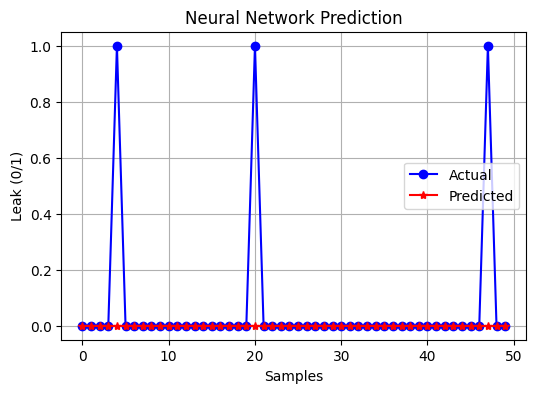

In [1]:
# ===========================================
# Smart Water Leakage Detection using Neural Network
# Handles Noisy and Incomplete Sensor Data
# ===========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -----------------------------
# Step 1: Generate Sensor Dataset
# -----------------------------
np.random.seed(42)

samples = 1000

pressure = np.random.normal(50,10,samples)
flow_rate = np.random.normal(30,5,samples)
vibration = np.random.normal(5,2,samples)
temperature = np.random.normal(25,3,samples)

# Leakage condition
leak = ((pressure < 45) &
         (flow_rate > 32) &
         (vibration > 6)).astype(int)

data = pd.DataFrame({
    'Pressure': pressure,
    'FlowRate': flow_rate,
    'Vibration': vibration,
    'Temperature': temperature,
    'Leak': leak
})

print("Original Dataset")
print(data.head())

# -----------------------------
# Step 2: Add Noise
# -----------------------------
noise = np.random.normal(0,2,data[['Pressure','FlowRate','Vibration','Temperature']].shape)

data[['Pressure','FlowRate','Vibration','Temperature']] += noise

print("\nNoise Added Successfully")

# -----------------------------
# Step 3: Introduce Missing Values
# -----------------------------
for col in ['Pressure','FlowRate','Vibration','Temperature']:
    data.loc[data.sample(frac=0.1).index,col] = np.nan

print("\nDataset with Missing Values")
print(data.isnull().sum())

# -----------------------------
# Step 4: Handle Missing Values
# -----------------------------
X = data.drop('Leak',axis=1)
y = data['Leak']

imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

# -----------------------------
# Step 5: Feature Scaling
# -----------------------------
scaler = StandardScaler()
X = scaler.fit_transform(X)

# -----------------------------
# Step 6: Split Dataset
# -----------------------------
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42)

# -----------------------------
# Step 7: Neural Network Model
# -----------------------------
model = MLPClassifier(
    hidden_layer_sizes=(16,8),
    activation='relu',
    max_iter=500,
    random_state=42
)

model.fit(X_train,y_train)

# -----------------------------
# Step 8: Prediction
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# Step 9: Accuracy
# -----------------------------
accuracy = accuracy_score(y_test,y_pred)

print("\nAccuracy =",round(accuracy*100,2),"%")

print("\nClassification Report")
print(classification_report(y_test,y_pred))

print("Confusion Matrix")
print(confusion_matrix(y_test,y_pred))

# -----------------------------
# Step 10: Plot Results
# -----------------------------
plt.figure(figsize=(6,4))
plt.plot(y_test.values[:50],'bo-',label='Actual')
plt.plot(y_pred[:50],'r*-',label='Predicted')
plt.xlabel("Samples")
plt.ylabel("Leak (0/1)")
plt.title("Neural Network Prediction")
plt.legend()
plt.grid(True)
plt.show()